In [1]:
##RQ 2

In [2]:
#obs 2.1 box plot

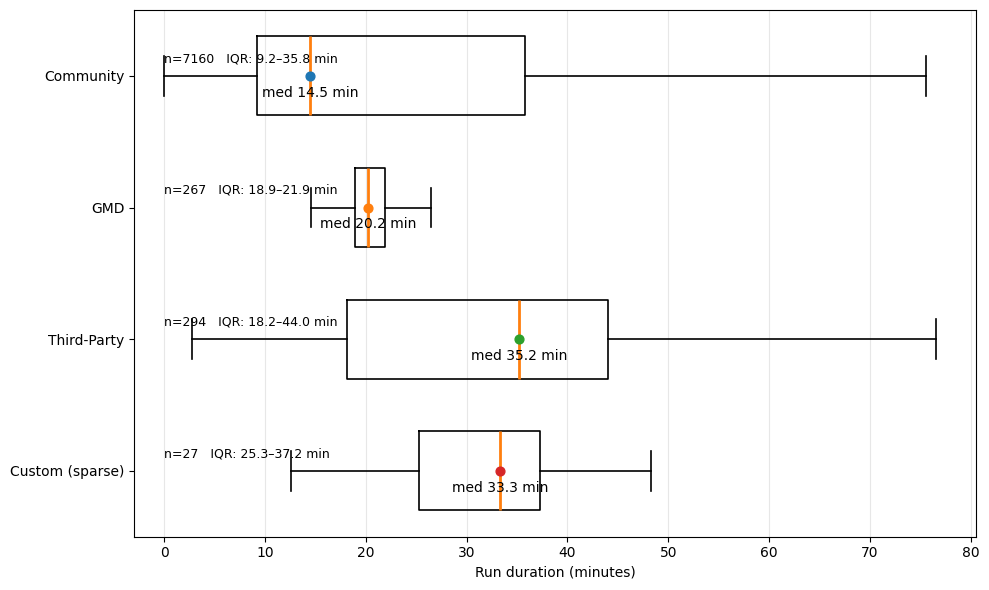

In [6]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# Load MainDataset
# =========================
ROOT_DIR = Path(r"C:\Android Mobile App\ICST2026_Ext")
IN_MAIN = ROOT_DIR / "MainDataset.csv"

df = pd.read_csv(IN_MAIN, low_memory=False)

# =========================
# Filter to Base regime + valid run duration
# =========================
df = df[df["Base"] == True].copy()
df["run_duration_seconds"] = pd.to_numeric(df["run_duration_seconds"], errors="coerce")
df = df[df["run_duration_seconds"].notna()].copy()

# Normalize style labels
df["style_plot"] = df["style"].replace({
    "Emu_Community": "Community",
    "Emu_Custom": "Custom",
})

style_order = ["Community", "GMD", "Third-Party", "Custom"]
df["style_plot"] = pd.Categorical(df["style_plot"], categories=style_order, ordered=True)
df = df[df["style_plot"].notna()].copy()

# Convert to minutes
df["run_duration_min"] = df["run_duration_seconds"] / 60.0

# =========================
# Build ordered data
# =========================
plot_data = []
labels = []
counts = []
medians = []
q1s = []
q3s = []
whisker_mins = []
whisker_maxs = []

for style in style_order:
    vals = df.loc[df["style_plot"] == style, "run_duration_min"].dropna().to_numpy()
    if len(vals) == 0:
        continue

    q1 = np.quantile(vals, 0.25)
    q3 = np.quantile(vals, 0.75)
    med = np.median(vals)
    iqr = q3 - q1

    # Tukey whiskers
    low_bound = q1 - 1.5 * iqr
    high_bound = q3 + 1.5 * iqr
    inside = vals[(vals >= low_bound) & (vals <= high_bound)]

    whisk_min = inside.min() if len(inside) else vals.min()
    whisk_max = inside.max() if len(inside) else vals.max()

    plot_data.append(vals)
    labels.append(style)
    counts.append(len(vals))
    medians.append(med)
    q1s.append(q1)
    q3s.append(q3)
    whisker_mins.append(whisk_min)
    whisker_maxs.append(whisk_max)

# =========================
# Draw plot
# =========================
fig, ax = plt.subplots(figsize=(10, 6))

bp = ax.boxplot(
    plot_data,
    vert=False,
    widths=0.6,
    patch_artist=False,
    showfliers=False,
    medianprops=dict(linewidth=2),
    whiskerprops=dict(linewidth=1.2),
    capprops=dict(linewidth=1.2),
    boxprops=dict(linewidth=1.2),
)

# Reverse order so Community appears on top
n = len(labels)
y_positions = np.arange(1, n + 1)
ax.set_yticks(y_positions)

display_labels = []
for lab in labels:
    if lab == "Custom":
        display_labels.append("Custom (sparse)")
    else:
        display_labels.append(lab)
ax.set_yticklabels(display_labels)

# Add median markers and annotations
for y, med, q1, q3, nobs, lab in zip(y_positions, medians, q1s, q3s, counts, labels):
    ax.scatter(med, y, zorder=3, s=40)
    ax.text(
        med,
        y + 0.18,
        f"med {med:.1f} min",
        ha="center",
        va="bottom",
        fontsize=10
    )
    ax.text(
        0.0,
        y - 0.18,
        f"n={nobs}   IQR: {q1:.1f}–{q3:.1f} min",
        ha="left",
        va="top",
        fontsize=9
    )

# Make layout similar to the reference image
ax.invert_yaxis()
ax.set_xlabel("Run duration (minutes)")
#ax.set_title(
#     "Obs. 2.1 preview — Run duration by style\n"
#     "Controller-filtered Base regime (verdict-complete, first attempt)"
# )
ax.grid(axis="x", alpha=0.3)

# Add some left padding for annotation visibility
xmin = min(0, min(whisker_mins) - 3)
xmax = max(whisker_maxs) + 4
ax.set_xlim(xmin, xmax)

plt.tight_layout()
plt.show()